In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

print("=== Data Wrangling ===")

df = pd.read_csv('Netflix Dataset.csv')
print(f"Ukuran awal dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

df.drop_duplicates(subset=['Show_Id'], inplace=True)
print(f"Ukuran setelah data duplikat dihapus: {df.shape[0]} baris")

df_movies = df[df['Category'] == 'Movie'].copy()

df_movies.dropna(subset=['Duration'], inplace=True)

df_movies['Duration_Num'] = df_movies['Duration'].str.extract('(\d+)').astype(int)
print(f"Jumlah data 'Movie' yang siap dianalisis: {df_movies['Duration_Num'].shape[0]} baris (Memenuhi syarat min. 5000 baris)")

=== Data Wrangling ===
Ukuran awal dataset: 7789 baris, 11 kolom
Ukuran setelah data duplikat dihapus: 7787 baris
Jumlah data 'Movie' yang siap dianalisis: 5377 baris (Memenuhi syarat min. 5000 baris)


<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Dzaky Al Hakim\AppData\Local\Temp\ipykernel_9724\3094161759.py:21: SyntaxWarning: invalid escape sequence '\d'
  df_movies['Duration_Num'] = df_movies['Duration'].str.extract('(\d+)').astype(int)


In [9]:
print("\n=== Analisis Deskriptif & Skewness ===")

mean_dur = df_movies['Duration_Num'].mean()
median_dur = df_movies['Duration_Num'].median()
mode_dur = df_movies['Duration_Num'].mode()[0]
skew_coef = df_movies['Duration_Num'].skew()

print(f"Mean (Rata-rata) Durasi : {mean_dur:.2f} menit")
print(f"Median (Nilai Tengah)    : {median_dur:.2f} menit")
print(f"Modus (Sering Muncul)    : {mode_dur:.2f} menit")
print(f"Koefisien Skewness       : {skew_coef:.4f}")

if skew_coef > 0:
    skew_type = "Positive Skewness (Miring Kanan)"
    reasoning = "Ekor kurva memanjang ke kanan. Mayoritas film Netflix berdurasi pendek-sedang, namun ada beberapa film dengan durasi sangat panjang (ekstrem)."
elif skew_coef < 0:
    skew_type = "Negative Skewness (Miring Kiri)"
    reasoning = "Ekor kurva memanjang ke kiri. Mayoritas film Netflix berdurasi panjang, namun ada beberapa film berdurasi sangat singkat (ekstrem)."
else:
    skew_type = "Symmetric Distribution (Normal)"
    reasoning = "Kurva seimbang, distribusi film berdurasi ideal merata."

print(f"Kesimpulan Bentuk Data   : {skew_type}")
print(f"Alasan Karakteristik     : {reasoning}")



=== Analisis Deskriptif & Skewness ===
Mean (Rata-rata) Durasi : 99.31 menit
Median (Nilai Tengah)    : 98.00 menit
Modus (Sering Muncul)    : 90.00 menit
Koefisien Skewness       : 0.1910
Kesimpulan Bentuk Data   : Positive Skewness (Miring Kanan)
Alasan Karakteristik     : Ekor kurva memanjang ke kanan. Mayoritas film Netflix berdurasi pendek-sedang, namun ada beberapa film dengan durasi sangat panjang (ekstrem).


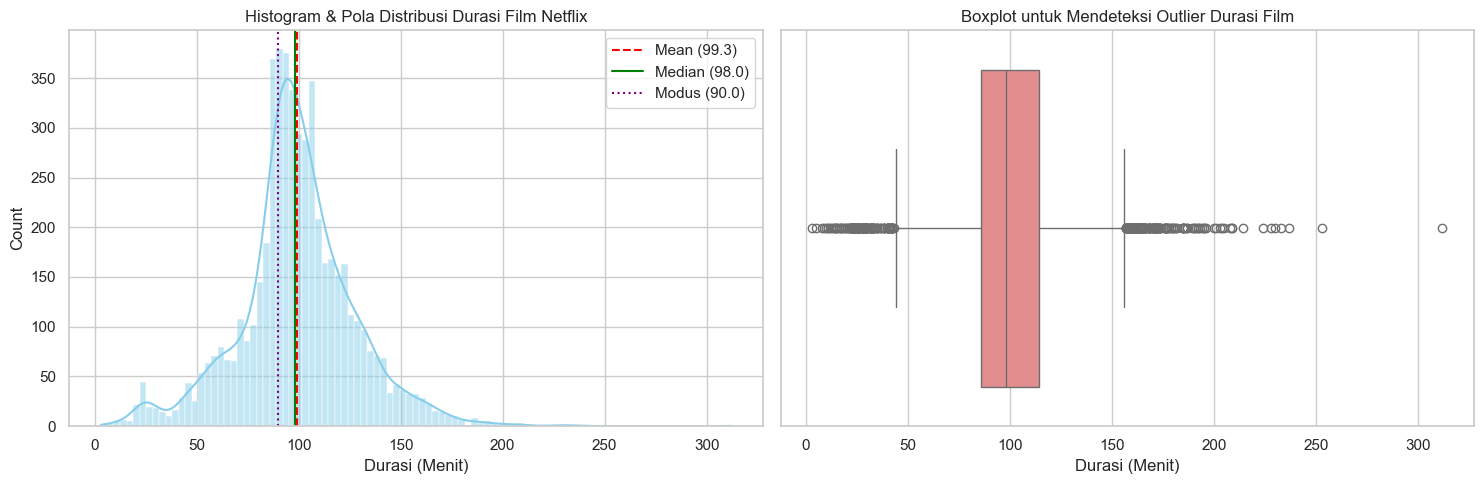

In [18]:
#Histogram
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_movies['Duration_Num'], kde=True, color='skyblue', ax=axes[0])
axes[0].axvline(mean_dur, color='red', linestyle='--', label=f'Mean ({mean_dur:.1f})')
axes[0].axvline(median_dur, color='green', linestyle='-', label=f'Median ({median_dur:.1f})')
axes[0].axvline(mode_dur, color='purple', linestyle=':', label=f'Modus ({mode_dur:.1f})')
axes[0].set_title('Histogram & Pola Distribusi Durasi Film Netflix')
axes[0].set_xlabel('Durasi (Menit)')
axes[0].legend()

#Boxplot
sns.boxplot(x=df_movies['Duration_Num'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot untuk Mendeteksi Outlier Durasi Film')
axes[1].set_xlabel('Durasi (Menit)')

plt.tight_layout()
plt.show()

In [17]:
print("=== Simulasi Monte Carlo ===")

# Alasan Metodologi Monte Carlo:
# Berdasarkan data historis durasi aktual, kita menghitung rata-rata dan standar deviasinya. 
# Parameter ini digunakan sebagai fondasi distribusi probabilitas normal stokastik untuk memproyeksikan durasi 100 film baru yang akan dirilis Netflix di masa mendatang.

std_dur = df_movies['Duration_Num'].std()
jumlah_proyeksi_film = 100
jumlah_simulasi = 1000

hasil_simulasi = np.zeros((jumlah_proyeksi_film, jumlah_simulasi))

np.random.seed(42)
for i in range(jumlah_simulasi):
    hasil_simulasi[:, i] = np.random.normal(loc=mean_dur, scale=std_dur, size=jumlah_proyeksi_film)

print(f"Simulasi Monte Carlo berhasil dijalankan sebanyak {jumlah_simulasi} iterasi.")
print(f"Proyeksi rata-rata keseluruhan durasi film masa depan: {np.mean(hasil_simulasi):.2f} menit")

=== Simulasi Monte Carlo ===
Simulasi Monte Carlo berhasil dijalankan sebanyak 1000 iterasi.
Proyeksi rata-rata keseluruhan durasi film masa depan: 99.34 menit


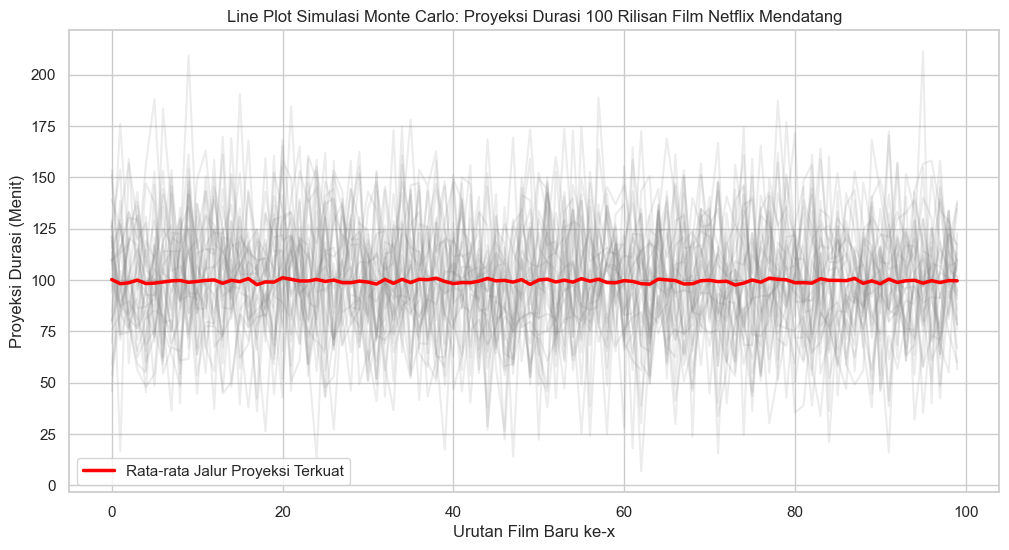

In [19]:
# Visualisasi Wajib 3: Line Plot Hasil Simulasi Monte Carlo
# Alasan: Line plot digunakan untuk menggambarkan penyebaran jalur proyeksi skenario masa depan yang dinamis dan fluktuatif dari simulasi stokastik.
plt.figure(figsize=(12, 6))
plt.plot(hasil_simulasi[:, :30], alpha=0.15, color='gray') # Menampilkan 30 jalur skenario sampel
plt.plot(np.mean(hasil_simulasi, axis=1), color='red', linewidth=2.5, label='Rata-rata Jalur Proyeksi Terkuat')
plt.title('Line Plot Simulasi Monte Carlo: Proyeksi Durasi 100 Rilisan Film Netflix Mendatang')
plt.xlabel('Urutan Film Baru ke-x')
plt.ylabel('Proyeksi Durasi (Menit)')
plt.legend()
plt.show()